K-means clustering is an unsupervised learning algorithm that classifies a data point based on the majority of its neighbors.

The algorithm is as follows:

- Choose the number of  and a distance metric.
- Decide how many clusters i want
- Find the nearest neighbors of the sample that we want to classify.
- Assign the class label by majority vote.
- Update the centroids of each class.
- Repeat the steps above until convergence.
- Note that because this algorithm takes distance into account, it is important that the features (columns) are on the same scale. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
df = pd.read_csv("../../dataset/flights.txt",sep="|")


In [3]:
df.iloc[0,:]

TRANSACTIONID                                                54548800
FLIGHTDATE                                                   20020101
AIRLINECODE                                                        WN
AIRLINENAME                                Southwest Airlines Co.: WN
TAILNUM                                                        N103@@
FLIGHTNUM                                                        1425
ORIGINAIRPORTCODE                                                 ABQ
ORIGAIRPORTNAME      AlbuquerqueNM: Albuquerque International Sunport
ORIGINCITYNAME                                            Albuquerque
ORIGINSTATE                                                        NM
ORIGINSTATENAME                                            New Mexico
DESTAIRPORTCODE                                                   DAL
DESTAIRPORTNAME                           DallasTX: Dallas Love Field
DESTCITYNAME                                                   Dallas
DESTSTATE           

In [4]:
df =df.loc[:,['AIRLINECODE','AIRLINENAME','DEPDELAY','ARRDELAY','TAXIOUT','ACTUALELAPSEDTIME','DISTANCE']]
df.head()

,AIRLINECODE,AIRLINENAME,DEPDELAY,ARRDELAY,TAXIOUT,ACTUALELAPSEDTIME,DISTANCE
0,WN,Southwest Airlines Co.: WN,0.0,-3.0,8.0,87.0,580 miles
1,CO,Continental Air Lines Inc.: CO,6.0,9.0,12.0,119.0,744 miles
2,WN,Southwest Airlines Co.: WN,83.0,80.0,7.0,102.0,718 miles
3,WN,Southwest Airlines Co.: WN,0.0,-2.0,5.0,83.0,487 miles
4,CO,Continental Air Lines Inc.: CO,-2.0,-3.0,11.0,114.0,744 miles


In [5]:
df[['DISTANCE','DistanceUnit']] = df['DISTANCE'].str.split(" ",expand=True)

In [6]:
df.head()

,AIRLINECODE,AIRLINENAME,DEPDELAY,ARRDELAY,TAXIOUT,ACTUALELAPSEDTIME,DISTANCE,DistanceUnit
0,WN,Southwest Airlines Co.: WN,0.0,-3.0,8.0,87.0,580,miles
1,CO,Continental Air Lines Inc.: CO,6.0,9.0,12.0,119.0,744,miles
2,WN,Southwest Airlines Co.: WN,83.0,80.0,7.0,102.0,718,miles
3,WN,Southwest Airlines Co.: WN,0.0,-2.0,5.0,83.0,487,miles
4,CO,Continental Air Lines Inc.: CO,-2.0,-3.0,11.0,114.0,744,miles


In [7]:
df.dtypes

AIRLINECODE           object
AIRLINENAME           object
DEPDELAY             float64
ARRDELAY             float64
TAXIOUT              float64
ACTUALELAPSEDTIME    float64
DISTANCE              object
DistanceUnit          object
dtype: object

In [8]:
df = df.astype({'DISTANCE':'int'})

In [9]:
df.dtypes

AIRLINECODE           object
AIRLINENAME           object
DEPDELAY             float64
ARRDELAY             float64
TAXIOUT              float64
ACTUALELAPSEDTIME    float64
DISTANCE               int32
DistanceUnit          object
dtype: object

In [10]:
df.isna().sum()

AIRLINECODE               0
AIRLINENAME               0
DEPDELAY              28335
ARRDELAY              31260
TAXIOUT              179972
ACTUALELAPSEDTIME     31260
DISTANCE                  0
DistanceUnit              0
dtype: int64

In [11]:
#tras realizar calculos, obtengo que los datos nulos representan el 2% de todos mis datos por lo cual lo
#mejor es desacerse de ellos
df.dropna(inplace=True)

In [12]:
#Definir el escalamiento de mis datos
'''
Para caracterizar aerolineas decido utilizar las siguientes caracteristicas
como mas representativas
DEPDELAY
TAXIOUT
ACTUALELAPSEDTIME
DISTANCE
'''
x = df.loc[:,['DEPDELAY','TAXIOUT','ACTUALELAPSEDTIME','DISTANCE']]

In [13]:
#Scikit standardScaler (Escalador que nos ofrece la libreria como estandar)
#Creo mi escalador
sc = StandardScaler()

In [14]:
#ajusto valores de media y desviacion estandar de mi x
sc.fit(x)

StandardScaler()

In [15]:
x_norm = sc.transform(x) #Realizo el escalamiento de cada uno de mis datos

In [16]:
x_norm

array([[-0.24483989, -0.70704122, -0.55630351, -0.29065784],
       [-0.04962741, -0.32118563, -0.10168907, -0.00355599],
       [ 2.45559937, -0.80350511, -0.343203  , -0.04907214],
       ...,
       [-0.24483989,  0.25759774,  0.19665166, -0.02631407],
       [-0.30991071,  0.54698943, -0.3574097 , -0.41670255],
       [-0.04962741,  1.12577281, -0.69837053, -0.770328  ]])

In [17]:
#aplicacion del metodo del codo, creo un arreglo con la cantidad de k que voy 
#a probar
clusters = np.arange(2,11)

In [18]:
inercias = []
for k in clusters:
    kmeans = KMeans(n_clusters=k,random_state=0) 
    kmeans.fit(x_norm)
    inercias.append(kmeans.inertia_)

In [19]:
eva = pd.DataFrame({"k":clusters,"inercia": inercias})

<AxesSubplot:xlabel='k', ylabel='inercia'>

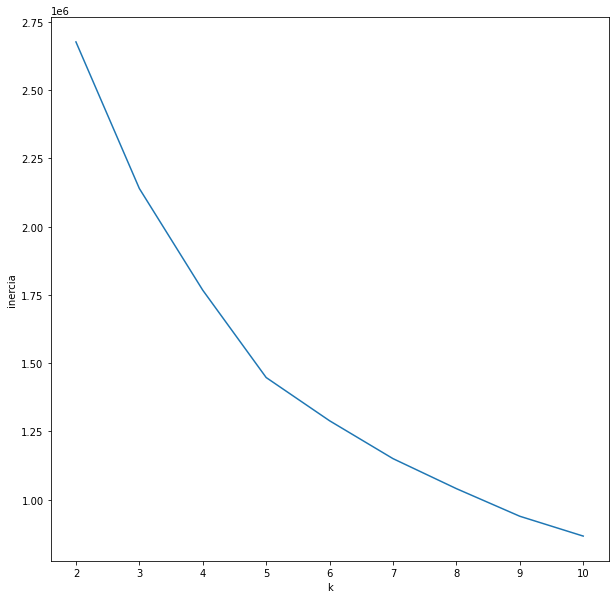

In [20]:
fig,ax = plt.subplots(figsize=(10,10))
sns.lineplot(data=eva,x="k",y="inercia")

In [21]:
#Segun el metodo del codo obtenemos que mi k recomendado es 3
kmeans = KMeans(n_clusters=5,random_state=0)

In [ ]:
# for Unsupervised algorithms we just use fir with the X data
# fit does not return a transformed dataset, it learns from the x_norm we sent and store it in the kmeans object
# from there we obtain the cluster_centers_, internally fit will do the iretation until it gets their centers

#If we wanted to assign the clusters to new data later we should use kmeans.predict(new_x_norm)
kmeans.fit(x_norm)

KMeans(n_clusters=5, random_state=0)

In [23]:
kmeans.cluster_centers_

array([[-0.15476485, -0.26443462, -0.68814954, -0.65957669],
       [ 4.01899622,  0.09359393, -0.05269028, -0.08989585],
       [ 0.07289334,  2.92858632,  0.36304084, -0.1171186 ],
       [-0.08775148,  0.22092392,  2.17925865,  2.24671928],
       [-0.15008202, -0.0491894 ,  0.40347579,  0.40351205]])

In [24]:
#Labels de mi dataset para cada una de mis observaciones
kmeans.labels_

array([0, 4, 1, ..., 4, 0, 0])

In [25]:
'''
AGREGO LOS LABELS A MI DATASET ORIGINAL
'''
df['cluster'] = kmeans.labels_

In [26]:
df.head()

,AIRLINECODE,AIRLINENAME,DEPDELAY,ARRDELAY,TAXIOUT,ACTUALELAPSEDTIME,DISTANCE,DistanceUnit,cluster
0,WN,Southwest Airlines Co.: WN,0.0,-3.0,8.0,87.0,580,miles,0
1,CO,Continental Air Lines Inc.: CO,6.0,9.0,12.0,119.0,744,miles,4
2,WN,Southwest Airlines Co.: WN,83.0,80.0,7.0,102.0,718,miles,1
3,WN,Southwest Airlines Co.: WN,0.0,-2.0,5.0,83.0,487,miles,0
4,CO,Continental Air Lines Inc.: CO,-2.0,-3.0,11.0,114.0,744,miles,4


In [27]:
df = df.loc[:,['AIRLINECODE','AIRLINENAME','DEPDELAY','ACTUALELAPSEDTIME','DISTANCE','cluster']]

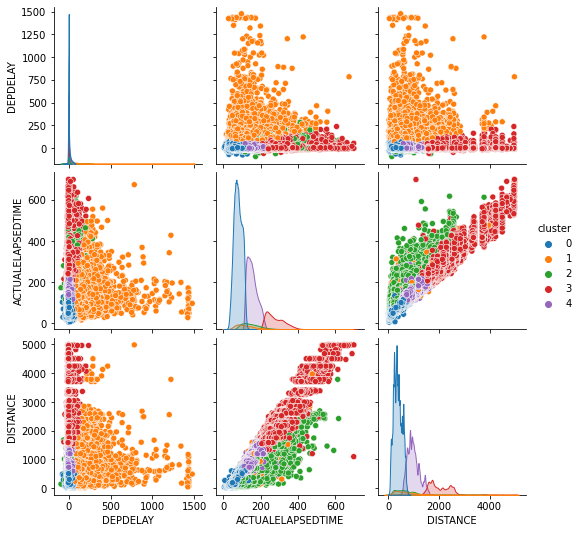

In [28]:
sns.pairplot(data=df,hue='cluster',palette = 'tab10')

In [29]:
#Caracterisicas grupo0
'''
mejor grupo para viajes de corta distancia
no presentan muchos retrasos en sus vuelos ni un elapsedTime alto, 
por lo cual llegan la mayoria de las veces en el tiempo estimado
'''
g0 = df.loc[df['cluster']==0]
g0.head()

,AIRLINECODE,AIRLINENAME,DEPDELAY,ACTUALELAPSEDTIME,DISTANCE,cluster
0,WN,Southwest Airlines Co.: WN,0.0,87.0,580,0
3,WN,Southwest Airlines Co.: WN,0.0,83.0,487,0
5,WN,Southwest Airlines Co.: WN,27.0,49.0,289,0
8,WN,Southwest Airlines Co.: WN,60.0,40.0,223,0
9,WN,Southwest Airlines Co.: WN,35.0,115.0,677,0


<AxesSubplot:xlabel='DISTANCE', ylabel='DEPDELAY'>

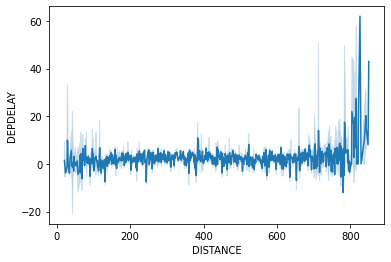

In [40]:
 sns.lineplot(data = g0,x='DISTANCE',y='DEPDELAY')

In [41]:
#Caracterisicas grupo1
'''
Grupo que mas retrasos tiene en departure
al realizar vaijes cortos

'''
g1 = df.loc[df['cluster']==1]

<AxesSubplot:xlabel='DISTANCE', ylabel='DEPDELAY'>

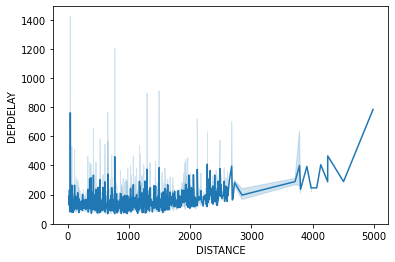

In [39]:
 sns.lineplot(data = g1,x='DISTANCE',y='DEPDELAY')

<h1>GRUPO 2<h1/>

In [31]:
#Caracterisicas grupo2
'''
Aerolineas promedio para realizar viajes cortos o largos
cumplen con su schedule arrival y suelen llegar incluso antes 
de lo programado

'''
g2 = df.loc[df['cluster']==2]

<AxesSubplot:xlabel='DISTANCE', ylabel='ACTUALELAPSEDTIME'>

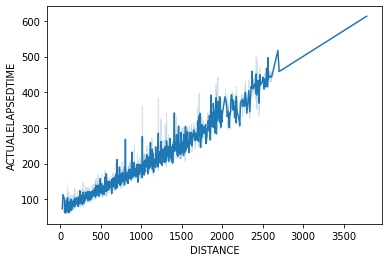

In [44]:
sns.lineplot(data = g2,x='DISTANCE',y='ACTUALELAPSEDTIME')

<h1>GRUPO 3<h1/>

In [54]:
#Caracterisicas grupo3
'''
Mejor Grupo para viajar largas distancias
Presetan demoras al despegar, Pero llegan antes
de lo programado a su destino la mayoria del tiempo
'''
g3 = df.loc[df['cluster']==3]

<AxesSubplot:xlabel='DISTANCE', ylabel='ACTUALELAPSEDTIME'>

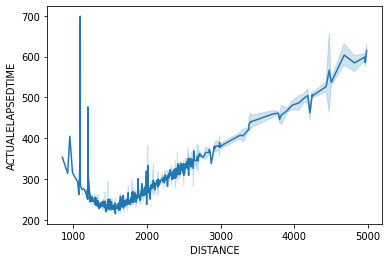

In [55]:
sns.lineplot(data = g3,x='DISTANCE',y='ACTUALELAPSEDTIME')

<h1>GRUPO 4<h1/>

In [46]:
#Caracterisicas grupo4
'''
Segundo mejor grupo para realizar viajes cortos
Presentan pocos retrasos para despegar y cumplen 
tienen un elapsed time bajo, lo que indica que
cumplen con su arrivo programado la mayoria del tiempo
o incluso llegan antes
'''
g4 = df.loc[df['cluster']==4]

<AxesSubplot:xlabel='DISTANCE', ylabel='DEPDELAY'>

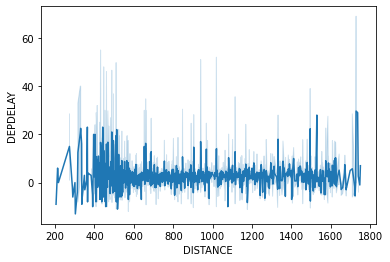

In [48]:
sns.lineplot(data = g4,x='DISTANCE',y='DEPDELAY')

<AxesSubplot:xlabel='DISTANCE', ylabel='ACTUALELAPSEDTIME'>

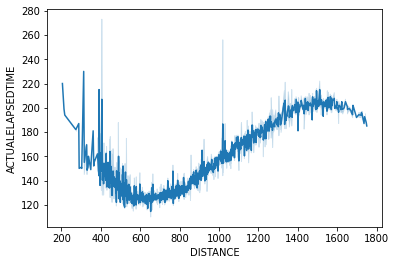

In [49]:
sns.lineplot(data = g4,x='DISTANCE',y='ACTUALELAPSEDTIME')

In [58]:
g1.head()

,AIRLINECODE,AIRLINENAME,DEPDELAY,ACTUALELAPSEDTIME,DISTANCE,cluster
2,WN,Southwest Airlines Co.: WN,83.0,102.0,718,1
6,DL,Delta Air Lines Inc.: DL,167.0,98.0,569,1
7,DL,Delta Air Lines Inc.: DL,105.0,163.0,1240,1
50,AA,American Airlines Inc.: AA,151.0,143.0,934,1
90,WN,Southwest Airlines Co.: WN,79.0,91.0,580,1
